Note Book de Jean-Olivier

In [1]:
import pandas as pd
import sqlite3

# Dans le fichier BRUT, il y a 4,271 lignes. On a nettoyé ce fichier.
# Dans le fichier CLEAN, il y a 4,145 lignes.
db_path = "../data/allergen_chip_challenge.db"

# On va lire les données allergies directement depuis la table dans la base de données :
conn = sqlite3.connect(db_path)

df = pd.read_sql("Select * From allergies", conn)
conn.close()

df.shape

(4271, 255)

In [2]:
df.iloc[:, 0:10].head()

,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,Region,Rural_area,Sensitization,Treatment_of_rhinitis,Treatment_of_asthma
0,FHB0001,ISAC_V1,20 à 40,1,11.0,regionB,0,1,Non renseigné,0
1,FHB0002,ISAC_V1,40 à 60,0,12.0,regionB,0,1,Non renseigné,0
2,FHB0003,ISAC_V1,10 à 20,1,1.0,regionB,0,0,Anti-H1 voie générale,0
3,FHB0004,ISAC_V1,10 à 20,0,1.0,regionB,0,1,Non renseigné,0
4,FHB0005,ISAC_V1,20 à 40,0,1.0,regionB,0,1,Non renseigné,0


In [3]:
df["Rural_area"].value_counts()

Rural_area
0    3305
1     966
Name: count, dtype: int64

In [4]:
df["Treatment_of_rhinitis"].value_counts()

Treatment_of_rhinitis
Non renseigné            2958
Aucun                     883
Anti-H1 voie générale     223
Anti-H1 + CS              115
Anti-H1, voie locale       92
Name: count, dtype: int64

In [5]:
df.iloc[:, 10:20].head()

,Age_of_onsets,Skin_Symptoms,General_cofactors,Treatment_of_atopic_dematitis,Act_d_1,Act_d_2,Act_d_5,Act_d_8,Aln_g_1,Alt_a_1
0,Non renseigné,0,Aucun,Non renseigné,0.0,0.0,0.0,0.0,0.00,0.0
1,Non renseigné,0,Aucun,Non renseigné,0.0,0.0,0.0,6.0,19.32,0.0
2,Aucun,0,Acariens,Non renseigné,0.0,0.0,0.0,0.0,0.00,0.0
3,Non renseigné,0,Aucun,Non renseigné,0.0,0.0,0.0,0.0,13.42,0.0
4,Non renseigné,0,Aucun,Non renseigné,0.0,0.0,0.0,0.0,0.00,0.0


In [6]:
df["Treatment_of_asthma"].value_counts()

Treatment_of_asthma
0    3668
1     603
Name: count, dtype: int64

In [7]:
df["Age_of_onsets"].value_counts()

Age_of_onsets
Non renseigné     2572
Aucun              622
0 - 2 ans          350
3 - 10 ans         296
20 ans et plus     150
10 - 20 ans        147
2 - 3 ans          134
Name: count, dtype: int64

In [8]:
df["Skin_Symptoms"].value_counts()

Skin_Symptoms
0    3131
1    1140
Name: count, dtype: int64

In [9]:
df["General_cofactors"].value_counts()

General_cofactors
Aucun                       3010
Animaux : cheval/rongeur     919
Effort/Activité sportive     141
Animaux : chat/chien          87
Acariens                      57
Moisissures                   36
Autres                        21
Name: count, dtype: int64

In [10]:
df["Treatment_of_atopic_dematitis"].value_counts()

Treatment_of_atopic_dematitis
Non renseigné        2689
Pas de traitement    1294
Dermocorticoïdes      122
Dupilumab              84
Autres                 82
Name: count, dtype: int64

In [11]:
df["Age"].value_counts()

Age
10 à 20      1252
0 à 10       1218
20 à 40       939
40 à 60       625
60 à Plus     237
Name: count, dtype: int64

In [12]:
df.shape

(4271, 255)

In [13]:
df2 = df.drop_duplicates()

df2.shape

(4271, 255)

In [14]:
# Choix parmi 241 colonnes de réactifs d'allergènes. Les corrélations avec la colonne globale de sensibilité permet d'isoler les meilleurs indicateurs.

corr_sensitization = []
best_corr_sensitization = []
best_columns = []
all_cols = df2.columns

for i in range(14, len(all_cols)):
    col = all_cols[i]
    c = df2[["Sensitization", col]].corr()
    value = float(c.iloc[0, 1])
    cval = value, col
    corr_sensitization.append(cval)

corr_sensitization.sort(reverse=True)
# Les 25 meilleures corrélations avec la variable cible :
best_corr_sensitization = corr_sensitization[:25]
best_columns = [z[1] for z in best_corr_sensitization]

best_corr_sensitization

[(0.19596531650876278, 'Phl_p_1'),
 (0.1927419238839798, 'Der_f_2'),
 (0.18779873132386596, 'Der_p_2'),
 (0.1684293240749237, 'Der_p_1'),
 (0.16465557154863045, 'Der_f_1'),
 (0.1642755649914333, 'Fel_d_1'),
 (0.16411831179015063, 'Bet_v_1'),
 (0.14407031788067245, 'Cup_a_1'),
 (0.13509128173855955, 'Cyn_d_1'),
 (0.13426649562779835, 'Ole_e_1'),
 (0.1279494327719592, 'Phl_p_5'),
 (0.12788109448799911, 'Phl_p_2'),
 (0.12521798436262319, 'Cor_a_1.0401'),
 (0.11937663839873613, 'Mal_d_1'),
 (0.11688741707719567, 'Cry_j_1'),
 (0.11582485449551094, 'Alt_a_1'),
 (0.11090537480496011, 'Aln_g_1'),
 (0.1094051177182328, 'Phl_p_4'),
 (0.10702815672286498, 'Phl_p_6'),
 (0.10491820264004241, 'Ara_h_6'),
 (0.1037788613260654, 'Lol_p_1'),
 (0.10236477328739942, 'Ara_h_2'),
 (0.09670140140704495, 'Can_f_1'),
 (0.09543058597573384, 'Cor_a_1.0103'),
 (0.09227112615670872, 'Cor_a_1.0101')]

In [15]:
# On force l'ajout du lait de vache, et du chien parmi les colonnes explicatives :
best_columns.append("Bos_d_8")
best_columns.append("Can_f_1")

# On enlève Der_p_1, Der_p_2 (car il est très similaire aux autres colonnes des acariens, Der_f_1, Der_f_2 est le gène majeur) :
if "Der_p_1" in best_columns:
    best_columns.remove("Der_p_1")
if "Der_p_2" in best_columns:
    best_columns.remove("Der_p_2")
# On enlève aussi Cor_a_1.0401 (la colonne entraîne de la colinéarité avec plusieurs colonnes)
if "Cor_a_1.0401" in best_columns:
    best_columns.remove("Cor_a_1.0401")

# On veut être sûr qu'il n'y a pas de doublons :
best_columns = list(set(best_columns))

len(best_columns)

23

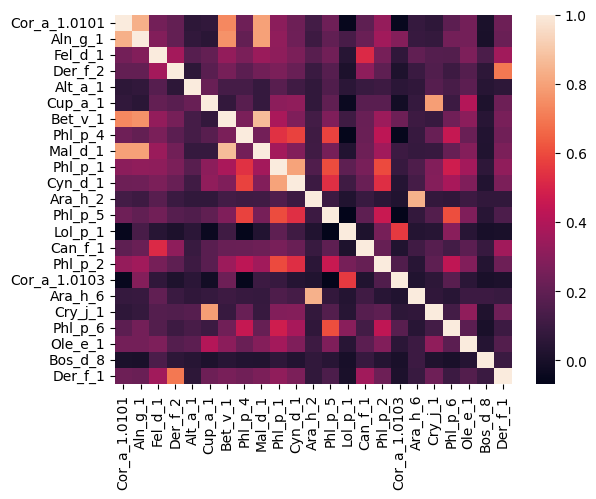

In [16]:
import seaborn as sns
from matplotlib import pyplot as plt

corr_df = df2[best_columns].corr()


# Doit-on ajouter des colonnes intéressantes ?
# Lait de vache ==> Bos_d_8
# Chien         ==> Can_f_1


sns.heatmap(corr_df)
plt.show()

In [17]:
left_columns = []

# Taking columns from the left hand, but not the row-id neither the Patient_ID:
for i in range(1, 14):
    left_columns.append(all_cols[i])

left_columns

['Chip_Type',
 'Age',
 'Gender',
 'Blood_Month_sample',
 'Region',
 'Rural_area',
 'Sensitization',
 'Treatment_of_rhinitis',
 'Treatment_of_asthma',
 'Age_of_onsets',
 'Skin_Symptoms',
 'General_cofactors',
 'Treatment_of_atopic_dematitis']

In [18]:
columns_to_keep = left_columns + best_columns

print(f"We will keep {len(columns_to_keep)} columns, as they seem interesting")

We will keep 36 columns, as they seem interesting


In [19]:
col_that_need_dummies = ['Chip_Type', 'Age', 'Blood_Month_sample', 'Region', 'Treatment_of_rhinitis', 'Age_of_onsets', 'General_cofactors', 'Treatment_of_atopic_dematitis']

# We keep only the columns to keep, and (for the pure categorical columns) we make some dummies.
df2 = df2[columns_to_keep]
df3 = pd.get_dummies(data=df2, columns=col_that_need_dummies, drop_first=True)

df3.shape


(4271, 80)

In [20]:
df3.head()

,Gender,Rural_area,Sensitization,Treatment_of_asthma,Skin_Symptoms,Cor_a_1.0101,Aln_g_1,Fel_d_1,Der_f_2,Alt_a_1,...,General_cofactors_Animaux : chat/chien,General_cofactors_Animaux : cheval/rongeur,General_cofactors_Aucun,General_cofactors_Autres,General_cofactors_Effort/Activité sportive,General_cofactors_Moisissures,Treatment_of_atopic_dematitis_Dermocorticoïdes,Treatment_of_atopic_dematitis_Dupilumab,Treatment_of_atopic_dematitis_Non renseigné,Treatment_of_atopic_dematitis_Pas de traitement
0,1,0,1,0,0,0.00,0.00,0.00,0.00,0.0,...,False,False,True,False,False,False,False,False,True,False
1,0,0,1,0,0,23.42,19.32,0.00,0.00,0.0,...,False,False,True,False,False,False,False,False,True,False
2,1,0,0,0,0,0.00,0.00,0.00,0.00,0.0,...,False,False,False,False,False,False,False,False,True,False
3,0,0,1,0,0,8.32,13.42,0.72,19.12,0.0,...,False,False,True,False,False,False,False,False,True,False
4,0,0,1,0,0,0.00,0.00,0.00,0.00,0.0,...,False,False,True,False,False,False,False,False,True,False


In [21]:
# Nous ne devrions jamais avoir de valeurs négatives dans le "min" de nos variables :

df3.iloc[:, 5:15].describe()

,Cor_a_1.0101,Aln_g_1,Fel_d_1,Der_f_2,Alt_a_1,Cup_a_1,Bet_v_1,Phl_p_4,Mal_d_1,Phl_p_1
count,4271.000000,4271.000000,4271.000000,4271.000000,4271.000000,4271.000000,4271.000000,4271.000000,4271.000000,4271.000000
mean,1.692381,2.155441,6.520623,12.354629,3.530915,5.871107,8.407886,1.693187,3.807307,12.032669
std,8.064502,8.536490,17.454383,28.184314,13.403492,17.904499,22.524260,6.799700,14.010807,26.991621
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.100000,3.915000,8.240000,0.000000,0.765000,2.025000,0.175000,0.270000,10.000000
max,184.380000,170.750000,222.610000,219.090000,205.760000,222.720000,221.560000,104.400000,197.490000,227.100000


In [22]:
from sklearn.model_selection import train_test_split

# Définition des colonnes qui sont dans X, et de la colonne qui est dans y :
X = df3.drop(columns=["Sensitization"])
y = df3["Sensitization"]


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# On peut centrer/réduire les données avec un SCALER (de type Standard {basé sur la moyenne} ou Robust {basé sur la médiane}) :

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaler.set_output(transform="pandas")

# Transformation autant pour X_train que pour X_test :
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)



In [23]:
X_train.head()

,Gender,Rural_area,Treatment_of_asthma,Skin_Symptoms,Cor_a_1.0101,Aln_g_1,Fel_d_1,Der_f_2,Alt_a_1,Cup_a_1,...,General_cofactors_Animaux : chat/chien,General_cofactors_Animaux : cheval/rongeur,General_cofactors_Aucun,General_cofactors_Autres,General_cofactors_Effort/Activité sportive,General_cofactors_Moisissures,Treatment_of_atopic_dematitis_Dermocorticoïdes,Treatment_of_atopic_dematitis_Dupilumab,Treatment_of_atopic_dematitis_Non renseigné,Treatment_of_atopic_dematitis_Pas de traitement
4046,-1.0,0.0,1.0,1.0,0.00,0.0,1.169533,6.804697,1.15,0.000000,...,0.0,0.0,-1.0,0.0,1.0,0.0,0.0,1.0,-1.0,0.0
2280,0.0,0.0,0.0,0.0,20.13,243.8,4.036855,0.000000,0.00,7.887006,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3936,-1.0,0.0,1.0,0.0,0.00,0.0,0.000000,0.000000,0.00,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0
2252,-1.0,0.0,0.0,0.0,0.00,0.0,0.000000,1.927070,2.78,26.011299,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3572,-1.0,1.0,0.0,1.0,4.74,142.2,0.442260,0.000000,0.00,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,1.0


In [25]:
# Lorsque les données à analyser sont "scalées" avec un Robust Scaler, et qu'on choisit un Random Forest Classifier, le score
# du modèle peut atteindre 0.92

from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()

rfc.fit(X=X_train, y=y_train)

score = rfc.score(X=X_test, y=y_test)

print(score)

0.900749063670412


In [26]:
my_cols = X_train.columns
should_remove = []

for my_col in my_cols:
    lbl = f"Without {my_col}"
    X_train_z = X_train.drop(columns=my_col)
    X_test_z = X_test.drop(columns=my_col)
    rfc_z = RandomForestClassifier()
    rfc_z.fit(X=X_train_z, y=y_train)
    score_z = rfc_z.score(X=X_test_z, y=y_test)
    if score_z > (score + 0.01):
        should_remove.append([score_z, lbl])

should_remove.sort(reverse=True)

print(f"Current score = {score}")
should_remove


Current score = 0.900749063670412


[]

In [27]:
nb_pathologiques = y_test.sum()
y_est = rfc.predict(X_test)
nb_pathologiques_pred = y_est.sum()

total_obs = len(y_test)

true_positive = (y_est==1) & (y_test==1)
nb_true_positive = true_positive.sum()

print(f"nb_pathologiques={nb_pathologiques}, nb_pathologiques_pred={nb_pathologiques_pred}, total_obs={total_obs}")

# Précision : ensemble des vrais positifs / ensemble des prédictions positives
PRECISION = nb_true_positive / nb_pathologiques_pred
naive_precision = nb_pathologiques / len(y_test)
print(f"PRECISION = {PRECISION}, NAIVE-PRECISION = {naive_precision}")

# Recall : ensemble des vrais positifs / ensemble des positifs réels
RECALL = nb_true_positive / nb_pathologiques
print(f"RECALL = {RECALL}")

F1_Score = 2 * (PRECISION*RECALL) / (PRECISION+RECALL)
print(f"F1_Score = {F1_Score}")

nb_pathologiques=878, nb_pathologiques_pred=880, total_obs=1068
PRECISION = 0.9386363636363636, NAIVE-PRECISION = 0.8220973782771536
RECALL = 0.9407744874715261
F1_Score = 0.9397042093287826


In [28]:
print(f"Rows in y_est = {len(y_est)}, Mean of sensitization estimated = {y_est.mean()}")

Rows in y_est = 1068, Mean of sensitization estimated = 0.8239700374531835


In [29]:
allergens_df = pd.read_csv("../data/allergens.csv")

allergens_df.head()

,allergen,name,molecular_mass,route
0,Aca f 1,Ole e 1-like protein,17 kDa,Airway
1,Aca f 2,Profilin,14.3 kDa,Airway
2,Aca s 13,Cytosolic fatty acid-binding protein,15 kDa,Airway
3,Aca s 2,NPC2 family; MD-2-related lipid recognition (M...,14 kDa,Airway
4,Act c 10,Non-specific lipid transfer protein type 1 (ns...,10 kDa,Food


In [30]:
dico = {}
for i in range(len(allergens_df)):
    dico[allergens_df.iloc[i, 0].strip()] = f"{allergens_df.iloc[i, 1]} / {allergens_df.iloc[i, 3]}"

len(allergens_df)

1155

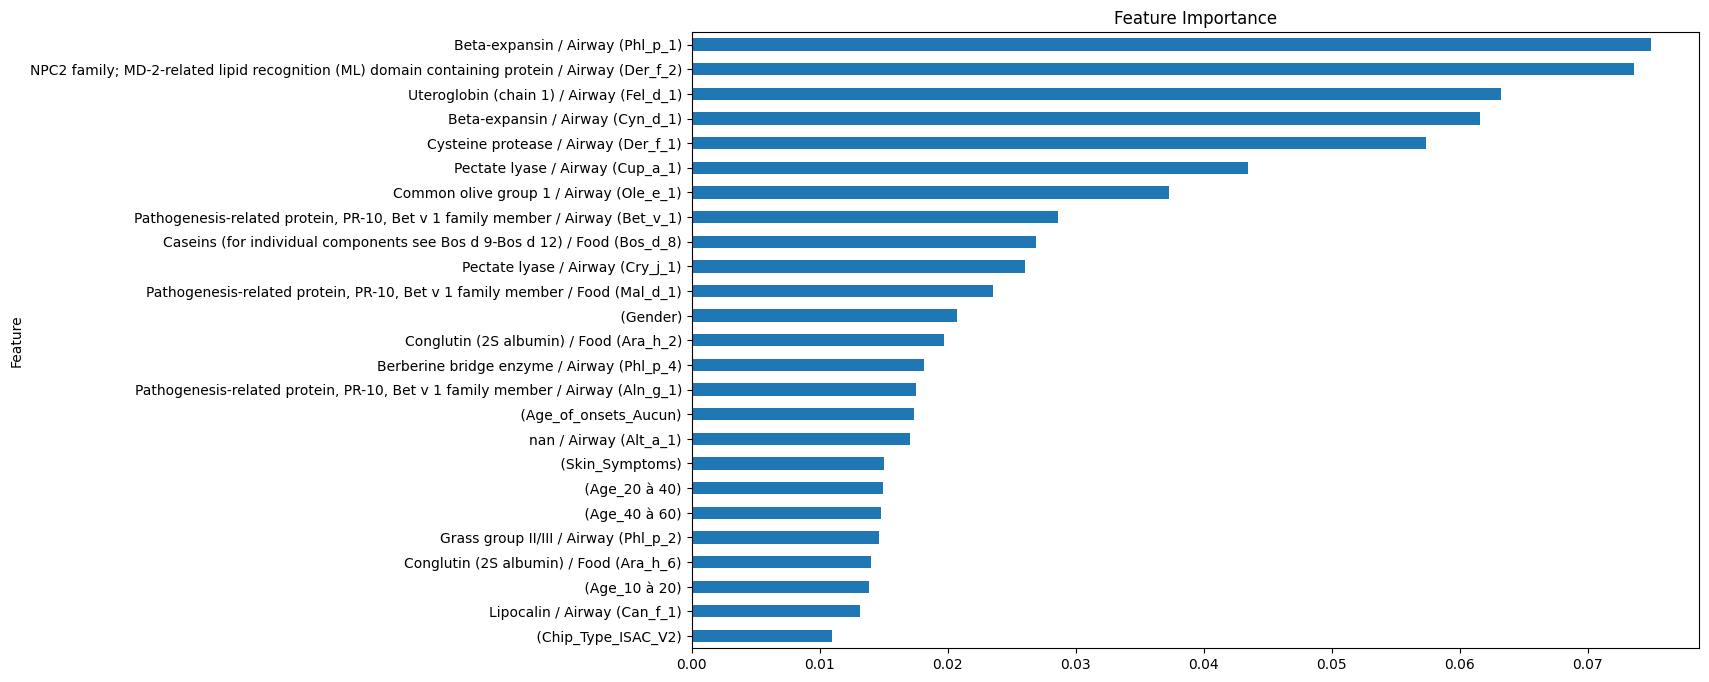

In [31]:
import matplotlib.pyplot as plt

# Get feature importances
index_labels = [f"{dico.get(z.replace('_', ' '), '')} ({z})" for z in X_train.columns]

importances = pd.Series(rfc.feature_importances_, index=index_labels)
importances = importances.sort_values(ascending=False)

# Top 25
importances_z = importances[:25]
importances_z = importances_z.sort_values(ascending=True)

# Plot
plt.figure(figsize=(13, 8))
importances_z.plot(kind='barh')
plt.title("Feature Importance")
plt.ylabel("Feature")
plt.show()

In [35]:
df3.head()

,Gender,Rural_area,Sensitization,Treatment_of_asthma,Skin_Symptoms,Cyn_d_1,Fel_d_1,Lol_p_1,Der_f_2,Phl_p_4,...,General_cofactors_Animaux : chat/chien,General_cofactors_Animaux : cheval/rongeur,General_cofactors_Aucun,General_cofactors_Autres,General_cofactors_Effort/Activité sportive,General_cofactors_Moisissures,Treatment_of_atopic_dematitis_Dermocorticoïdes,Treatment_of_atopic_dematitis_Dupilumab,Treatment_of_atopic_dematitis_Non renseigné,Treatment_of_atopic_dematitis_Pas de traitement
0,1,0,1,0,0,0.00,0.00,0.0,0.00,0.00,...,False,False,True,False,False,False,False,False,True,False
1,0,0,1,0,0,0.00,0.00,0.0,0.00,0.00,...,False,False,True,False,False,False,False,False,True,False
2,1,0,0,0,0,0.00,0.00,0.0,0.00,0.00,...,False,False,False,False,False,False,False,False,True,False
3,0,0,1,0,0,46.86,0.72,0.0,19.12,8.84,...,False,False,True,False,False,False,False,False,True,False
4,0,0,1,0,0,50.83,0.00,0.0,0.00,0.00,...,False,False,True,False,False,False,False,False,True,False
